# EDA de PM2.5 en Santa Anita

**Primera entrega — enero de 2022 a abril de 2024**

Buscamos predecir la concentración de PM2.5 exactamente una hora después usando su historial reciente y estudiar el aporte de la hora del día y del día de la semana. Esta notebook desarrolla el análisis exploratorio, sin entrenar modelos.

Fuente: [SENAMHI — Plataforma Nacional de Datos Abiertos](https://www.datosabiertos.gob.pe/dataset/monitoreo-de-los-contaminantes-del-aire-en-lima-metropolitana-servicio-nacional-de). Licencia indicada: Open Data Commons Attribution License. El CSV fue filtrado por el equipo para conservar Santa Anita. Se mantiene intacto en `data/raw/`.

Se sigue la secuencia de la notebook del curso `session-01c-eda-and-cleaning.ipynb`: estructura, calidad, resúmenes y decisiones de preparación. Los gráficos se guardan en PNG (300 dpi) y PDF vectorial en `figures/`; las tablas, en `data/processed/`.

**Unidad:** el diccionario revisado no especifica la unidad de las concentraciones. Los ejes usan «unidad del archivo» hasta confirmarla con SENAMHI. No se comparan estos valores con umbrales sanitarios.


## 1. Carga de datos
Ejecutar las celdas en orden desde la raíz del repositorio o desde `notebooks/`. No se necesitan rutas personales.


In [1]:
from pathlib import Path
import hashlib
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if not (ROOT / 'data/raw/santa_anita_2015_2024.csv').exists():
    ROOT = ROOT.parent
CSV = ROOT / 'data/raw/santa_anita_2015_2024.csv'
assert CSV.exists(), 'Abrir la notebook desde la raíz del repositorio o notebooks/.'
FIG = ROOT / 'figures'
OUT = ROOT / 'data/processed'
FIG.mkdir(exist_ok=True)
OUT.mkdir(exist_ok=True)
hash_original = hashlib.sha256(CSV.read_bytes()).hexdigest()
plt.rcParams.update({'figure.figsize': (8, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'savefig.facecolor': 'white'})
COLOR = '#176B87'
UNIDAD = 'PM2.5 (unidad del archivo)'
def guardar(fig, nombre):
    fig.tight_layout()
    fig.savefig(FIG / f'{nombre}.png', dpi=300, bbox_inches='tight')
    fig.savefig(FIG / f'{nombre}.pdf', bbox_inches='tight')
    plt.show()
    plt.close(fig)
def tabla(df, nombre):
    df.to_csv(OUT / f'{nombre}.csv', encoding='utf-8', index=True)
    vista = df.copy()
    numericas = vista.select_dtypes(include="number").columns
    vista[numericas] = vista[numericas].round(3)
    display(vista)

raw = pd.read_csv(CSV, dtype={'FECHA': 'string', 'HORA': 'string', 'UBIGEO': 'string'})
print(f'Archivo de Santa Anita: {raw.shape[0]:,} filas y {raw.shape[1]} columnas.')
display(raw.head())
raw.info()
print('Versiones:', platform.python_version(), 'pandas', pd.__version__,
      'numpy', np.__version__, 'matplotlib', matplotlib.__version__)


Archivo de Santa Anita: 82,542 filas y 15 columnas.


,ID,ESTACION,FECHA,HORA,LONGITUD,LATITUD,ALTITUD,PM10,PM2_5,NO2,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO,FECHA_CORTE
0,165085,SANTA_ANITA,20150101,50000,-76.9714,-12.043,253,103.93,13.4,NaN,LIMA,LIMA,SANTA_ANITA,150137,20240531
1,165086,SANTA_ANITA,20150101,60000,-76.9714,-12.043,253,293.73,102.4,NaN,LIMA,LIMA,SANTA_ANITA,150137,20240531
2,165087,SANTA_ANITA,20150101,70000,-76.9714,-12.043,253,168.25,118.8,NaN,LIMA,LIMA,SANTA_ANITA,150137,20240531
3,165088,SANTA_ANITA,20150101,80000,-76.9714,-12.043,253,165.57,87.9,NaN,LIMA,LIMA,SANTA_ANITA,150137,20240531
4,165089,SANTA_ANITA,20150101,90000,-76.9714,-12.043,253,81.51,66.7,NaN,LIMA,LIMA,SANTA_ANITA,150137,20240531


<class 'pandas.DataFrame'>
RangeIndex: 82542 entries, 0 to 82541
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            82542 non-null  int64  
 1   ESTACION      82542 non-null  str    
 2   FECHA         82542 non-null  string 
 3   HORA          82542 non-null  string 
 4   LONGITUD      82542 non-null  float64
 5   LATITUD       82542 non-null  float64
 6   ALTITUD       82542 non-null  int64  
 7   PM10          68300 non-null  float64
 8   PM2_5         50613 non-null  float64
 9   NO2           44450 non-null  float64
 10  DEPARTAMENTO  82542 non-null  str    
 11  PROVINCIA     82542 non-null  str    
 12  DISTRITO      82542 non-null  str    
 13  UBIGEO        82542 non-null  string 
 14  FECHA_CORTE   82542 non-null  int64  
dtypes: float64(5), int64(3), str(4), string(3)
memory usage: 9.4 MB
Versiones: 3.12.14 pandas 3.0.1 numpy 2.5.3 matplotlib 3.11.2


## 2. Selección del periodo de estudio
Primero comprobamos las fechas y la estación. El gráfico histórico cuenta horas con al menos una medición disponible; no promedia ni selecciona las concentraciones duplicadas. En 2015 se incluyen las cinco primeras horas del año en el denominador, aunque el archivo empieza a las 05:00. En 2024 solo se incluyen enero–mayo.


Periodo del archivo: 2015-01-01 05:00:00 a 2024-05-31 23:00:00
Registros adicionales con fecha/hora repetida: 12


,horas_esperadas,horas_con_PM25,cobertura_pct
2015,8760,8250,94.178
2016,8784,7434,84.631
2017,8760,8258,94.269
2018,8760,4397,50.194
2019,8760,1832,20.913
2020,8784,0,0.000
2021,8760,303,3.459
2022,8760,8236,94.018
2023,8760,8326,95.046
2024,3648,3565,97.725


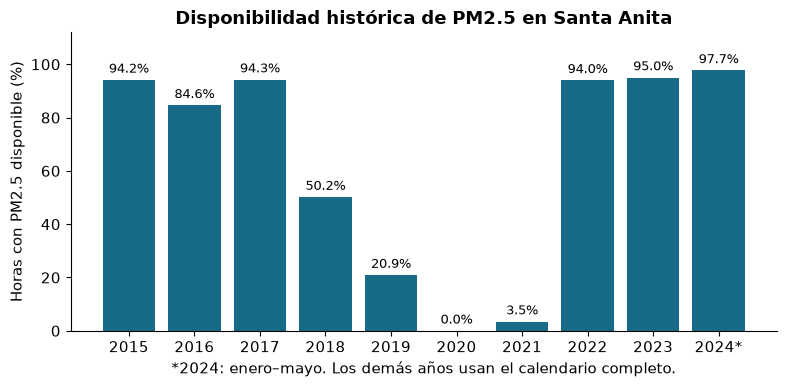

In [2]:
datos = raw.copy()
datos['fecha_hora'] = pd.to_datetime(
    datos['FECHA'] + datos['HORA'].str.zfill(6),
    format='%Y%m%d%H%M%S', errors='coerce')
assert datos['fecha_hora'].notna().all(), 'Revisar fechas que no pudieron interpretarse.'
assert set(datos['ESTACION'].unique()) == {'SANTA_ANITA'}
assert datos['fecha_hora'].eq(datos['fecha_hora'].dt.floor('h')).all()
print('Periodo del archivo:', datos['fecha_hora'].min(), 'a', datos['fecha_hora'].max())
print('Registros adicionales con fecha/hora repetida:', datos['fecha_hora'].duplicated().sum())
disponible = datos.assign(disponible=datos['PM2_5'].notna()).groupby('fecha_hora')['disponible'].any()
rejilla_hist = pd.date_range('2015-01-01', '2024-05-31 23:00', freq='h')
hist = disponible.reindex(rejilla_hist, fill_value=False)
cob_anual = hist.groupby(hist.index.year).agg(['size', 'sum'])
cob_anual.columns = ['horas_esperadas', 'horas_con_PM25']
cob_anual['cobertura_pct'] = 100 * cob_anual.horas_con_PM25 / cob_anual.horas_esperadas
tabla(cob_anual, 'cobertura_anual_historica')
fig, ax = plt.subplots(figsize=(8, 4))
etiquetas = [str(y) if y != 2024 else '2024*' for y in cob_anual.index]
barras = ax.bar(etiquetas, cob_anual.cobertura_pct, color=COLOR)
ax.bar_label(barras, labels=[f'{v:.1f}%' for v in cob_anual.cobertura_pct], fontsize=9, padding=3)
ax.set(ylabel='Horas con PM2.5 disponible (%)', ylim=(0, 112),
       title='Disponibilidad histórica de PM2.5 en Santa Anita')
ax.set_xlabel('*2024: enero–mayo. Los demás años usan el calendario completo.')
guardar(fig, '01_cobertura_anual')


In [3]:
INICIO = pd.Timestamp('2022-01-01 00:00')
FIN = pd.Timestamp('2024-04-30 23:00')
periodo = datos.loc[datos.fecha_hora.between(INICIO, FIN)].sort_values('fecha_hora').copy()
assert not periodo.fecha_hora.duplicated().any(), 'Resolver duplicados antes de continuar.'
rejilla = pd.date_range(INICIO, FIN, freq='h', name='fecha_hora')
horas_sin_fila = len(rejilla.difference(pd.DatetimeIndex(periodo.fecha_hora)))
df = periodo.set_index('fecha_hora').reindex(rejilla)
s = df['PM2_5']
resumen = pd.DataFrame({'valor': {
    'Horas esperadas': len(rejilla), 'Filas en el periodo': len(periodo),
    'Horas sin fila': horas_sin_fila, 'Mediciones PM2.5 disponibles': s.count(),
    'PM2.5 faltantes': s.isna().sum(), 'Cobertura (%)': 100*s.notna().mean(),
    'Duplicados fecha/hora': periodo.fecha_hora.duplicated().sum()}})
tabla(resumen, 'resumen_periodo')
display(Markdown(f'El periodo contiene **{len(df):,} horas**, con **{s.count():,} mediciones** '
                 f'y **{s.isna().sum():,} faltantes** de PM2.5. La cobertura es **{100*s.notna().mean():.2f}%**. '
                 'La ausencia de duplicados se refiere a este periodo, no al archivo histórico completo.'))


,valor
Horas esperadas,20424.000
Filas en el periodo,20424.000
Horas sin fila,0.000
Mediciones PM2.5 disponibles,19391.000
PM2.5 faltantes,1033.000
Cobertura (%),94.942
Duplicados fecha/hora,0.000


El periodo contiene **20,424 horas**, con **19,391 mediciones** y **1,033 faltantes** de PM2.5. La cobertura es **94.94%**. La ausencia de duplicados se refiere a este periodo, no al archivo histórico completo.

La cobertura histórica muestra que no todos los años ofrecen la misma continuidad. Elegimos 2022–abril de 2024 por su disponibilidad y porque no contiene duplicados horarios. Mayo de 2024 queda fuera del alcance definido y presenta duplicados en el archivo histórico. Esta selección limita las conclusiones a un periodo relativamente bien observado; no demuestra que los faltantes sean aleatorios.


## 3. Estructura y tipos de variables
Los códigos y fechas se distinguen de las magnitudes continuas. PM10 y NO2 se revisan para describir el archivo, pero no se incluyen en la comparación predictiva propuesta.


In [4]:
roles = {
 'ID': ('Identificador', 'Excluir'), 'ESTACION': ('Categórica', 'Contexto: una estación'),
 'FECHA': ('Temporal', 'Combinar con HORA'), 'HORA': ('Temporal', 'Combinar con FECHA'),
 'LONGITUD': ('Numérica', 'Ubicación'), 'LATITUD': ('Numérica', 'Ubicación'),
 'ALTITUD': ('Numérica', 'Ubicación'), 'PM10': ('Numérica continua', 'Descriptiva'),
 'PM2_5': ('Numérica continua', 'Historial y respuesta futura'),
 'NO2': ('Numérica continua', 'Descriptiva'),
 'DEPARTAMENTO': ('Categórica', 'Contexto'), 'PROVINCIA': ('Categórica', 'Contexto'),
 'DISTRITO': ('Categórica', 'Contexto'), 'UBIGEO': ('Código', 'Contexto'),
 'FECHA_CORTE': ('Temporal', 'Excluir: corte del archivo')}
variables = pd.DataFrame(roles, index=['tipo_conceptual', 'uso']).T
variables['tipo_en_python'] = raw.dtypes.astype(str)
variables['valores_distintos_periodo'] = df[raw.columns].nunique()
tabla(variables, 'variables')


,tipo_conceptual,uso,tipo_en_python,valores_distintos_periodo
ID,Identificador,Excluir,int64,20424
ESTACION,Categórica,Contexto: una estación,str,1
FECHA,Temporal,Combinar con HORA,string,851
HORA,Temporal,Combinar con FECHA,string,24
LONGITUD,Numérica,Ubicación,float64,1
LATITUD,Numérica,Ubicación,float64,1
ALTITUD,Numérica,Ubicación,int64,1
PM10,Numérica continua,Descriptiva,float64,6573
PM2_5,Numérica continua,Historial y respuesta futura,float64,5683
NO2,Numérica continua,Descriptiva,float64,1350


La respuesta será $y_t = PM_{2.5}(t+1)$, con una separación exacta de una hora. Las entradas usarán mediciones disponibles hasta $t$ y, en el segundo enfoque, la hora y el día de la semana de $t+1$, conocidos de antemano. Tener una medición no garantiza disponer de la respuesta siguiente ni de todo el historial requerido.


## 4. Calidad de datos y valores faltantes
No reemplazamos faltantes por cero ni interpolamos. Se cuantifican tanto las celdas vacías como los tramos consecutivos sin medición.


,faltantes,faltantes_pct
ID,0,0.000
ESTACION,0,0.000
FECHA,0,0.000
HORA,0,0.000
LONGITUD,0,0.000
LATITUD,0,0.000
ALTITUD,0,0.000
PM10,1753,8.583
PM2_5,1033,5.058
NO2,1530,7.491


,negativos,ceros,infinitos
PM10,0,0,0
PM2_5,0,0,0
NO2,0,0,0


,horas_esperadas,mediciones,media,mediana,faltantes,cobertura_pct
fecha_hora,,,,,,
2022-01-01,744,612,20.648,18.455,132,82.258
2022-02-01,672,655,21.525,20.170,17,97.470
2022-03-01,744,744,22.202,21.440,0,100.000
2022-04-01,720,709,31.589,26.960,11,98.472
2022-05-01,744,714,51.965,45.470,30,95.968
2022-06-01,720,650,53.741,48.200,70,90.278
2022-07-01,744,716,48.500,45.570,28,96.237
2022-08-01,744,724,54.020,49.165,20,97.312
2022-09-01,720,690,48.028,44.375,30,95.833


,inicio,fin,horas
grupo,,,
4,2022-01-17 11:00:00,2022-01-22 16:00:00,126
74,2023-07-27 03:00:00,2023-07-31 21:00:00,115
62,2023-03-10 23:00:00,2023-03-14 21:00:00,95
54,2022-12-17 02:00:00,2022-12-19 21:00:00,68
72,2023-07-22 07:00:00,2023-07-24 21:00:00,63
46,2022-10-15 20:00:00,2022-10-17 13:00:00,42
58,2023-02-20 03:00:00,2023-02-21 18:00:00,40
76,2023-08-03 03:00:00,2023-08-04 17:00:00,39
26,2022-06-29 00:00:00,2022-06-30 12:00:00,37


La mayor interrupción de PM2.5 dura **126 horas**. Las fechas de la tabla incluyen la primera y la última hora sin medición. El CSV por sí solo no permite determinar la causa de estas interrupciones.

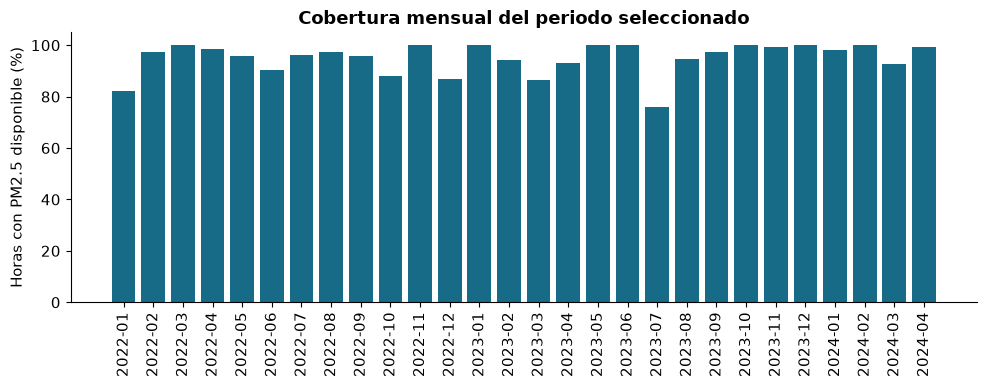

In [5]:
calidad = pd.DataFrame({'faltantes': df[raw.columns].isna().sum(),
                        'faltantes_pct': df[raw.columns].isna().mean()*100})
tabla(calidad, 'faltantes_por_variable')
contaminantes = df[['PM10', 'PM2_5', 'NO2']]
validacion = pd.DataFrame({'negativos': contaminantes.lt(0).sum(),
                           'ceros': contaminantes.eq(0).sum(),
                           'infinitos': np.isinf(contaminantes).sum()})
tabla(validacion, 'validacion_concentraciones')
mensual = s.resample('MS').agg(['size', 'count', 'mean', 'median'])
mensual.columns = ['horas_esperadas', 'mediciones', 'media', 'mediana']
mensual['faltantes'] = mensual.horas_esperadas - mensual.mediciones
mensual['cobertura_pct'] = 100*mensual.mediciones/mensual.horas_esperadas
tabla(mensual, 'resumen_mensual')
mask = s.isna()
grupos = mask.ne(mask.shift()).cumsum()
huecos = pd.DataFrame({'fecha': df.index, 'faltante': mask.to_numpy(), 'grupo': grupos.to_numpy()})
huecos = huecos.loc[huecos.faltante].groupby('grupo').agg(
    inicio=('fecha', 'min'), fin=('fecha', 'max'), horas=('fecha', 'size')).sort_values('horas', ascending=False)
tabla(huecos.head(10), 'mayores_interrupciones')
max_hueco = int(huecos.horas.max()) if len(huecos) else 0
display(Markdown(f'La mayor interrupción de PM2.5 dura **{max_hueco} horas**. '
                 'Las fechas de la tabla incluyen la primera y la última hora sin medición. '
                 'El CSV por sí solo no permite determinar la causa de estas interrupciones.'))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(mensual.index.strftime('%Y-%m'), mensual.cobertura_pct, color=COLOR)
ax.set(ylabel='Horas con PM2.5 disponible (%)', ylim=(0,105), title='Cobertura mensual del periodo seleccionado')
ax.tick_params(axis='x', rotation=90)
guardar(fig, '02_cobertura_mensual')


## 5. Estadísticas descriptivas
Se calculan sobre las concentraciones disponibles de PM2.5, sin imputación. Las observaciones son horarias y no independientes entre sí.


In [6]:
estadisticas = s.describe(percentiles=[.25, .5, .75, .95, .99]).to_frame('PM2.5')
estadisticas.loc['asimetria'] = s.skew()
tabla(estadisticas, 'estadisticas_pm25')
display(Markdown(f'La media es **{s.mean():.2f}** y la mediana **{s.median():.2f}** '
                 f'(unidad del archivo). El 50% central de las mediciones está entre '
                 f'**{s.quantile(.25):.2f} y {s.quantile(.75):.2f}**. '
                 f'El rango observado va de **{s.min():.2f} a {s.max():.2f}**. '
                 'La comparación entre media, mediana y percentiles ayuda a evaluar el efecto de los valores altos.'))


,PM2.5
count,19391.000
mean,29.290
std,18.166
min,3.432
25%,17.450
50%,24.500
75%,35.515
95%,65.305
99%,95.010
max,191.500


La media es **29.29** y la mediana **24.50** (unidad del archivo). El 50% central de las mediciones está entre **17.45 y 35.52**. El rango observado va de **3.43 a 191.50**. La comparación entre media, mediana y percentiles ayuda a evaluar el efecto de los valores altos.

## 6. Distribución y posibles valores atípicos
La regla de 1,5 veces el rango intercuartílico (IQR) identifica valores para revisar; no prueba errores de medición. No se elimina ninguna observación por esta regla.


,valor
Limite inferior IQR,-9.648
Limite superior IQR,62.613
Mediciones señaladas,1126.000
Porcentaje de disponibles,5.807


,PM2.5
fecha_hora,
2022-08-14 13:00:00,191.5
2022-05-22 11:00:00,191.4
2022-05-29 13:00:00,181.4
2022-05-24 13:00:00,177.4
2022-07-02 11:00:00,176.5
2022-05-29 14:00:00,175.0
2022-04-29 13:00:00,170.7
2022-05-25 14:00:00,168.5
2022-05-22 10:00:00,166.9


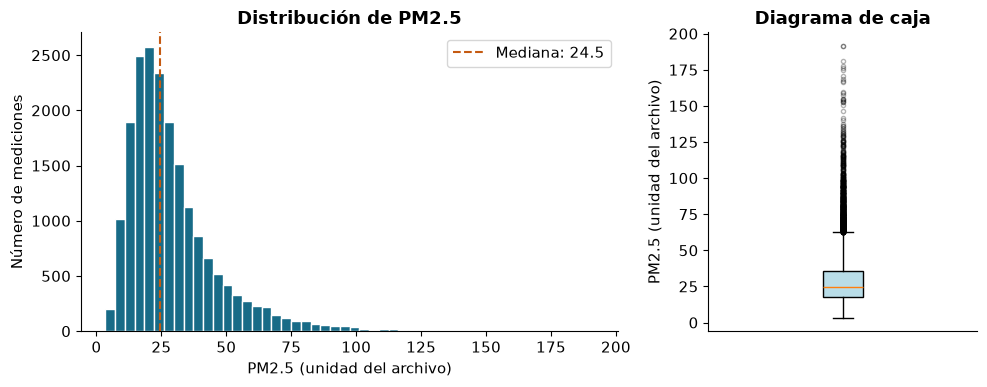

La regla IQR señala **1,126 mediciones** (**5.81%** de las disponibles). Se conservan porque podrían corresponder a episodios reales. Para clasificarlas como errores haría falta información de validación o mantenimiento de la estación.

In [7]:
q1, q3 = s.quantile([.25, .75])
iqr = q3-q1
inferior, superior = q1-1.5*iqr, q3+1.5*iqr
atipicos = s.lt(inferior) | s.gt(superior)
tabla(pd.DataFrame({'valor': {'Limite inferior IQR': inferior, 'Limite superior IQR': superior,
    'Mediciones señaladas': atipicos.sum(), 'Porcentaje de disponibles': 100*atipicos.sum()/s.count()}}), 'revision_atipicos')
tabla(s.nlargest(10).to_frame('PM2.5'), 'mayores_concentraciones')
fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios':[2,1]})
axes[0].hist(s.dropna(), bins=50, color=COLOR, edgecolor='white')
axes[0].axvline(s.median(), color='#C55A11', linestyle='--', label=f'Mediana: {s.median():.1f}')
axes[0].set(xlabel=UNIDAD, ylabel='Número de mediciones', title='Distribución de PM2.5')
axes[0].legend()
axes[1].boxplot(s.dropna(), patch_artist=True, boxprops={'facecolor':'#B9DDE8'},
                flierprops={'markersize':3, 'alpha':.3})
axes[1].set(ylabel=UNIDAD, xticks=[], title='Diagrama de caja')
guardar(fig, '03_distribucion_pm25')
display(Markdown(f'La regla IQR señala **{atipicos.sum():,} mediciones** '
                 f'(**{100*atipicos.sum()/s.count():.2f}%** de las disponibles). '
                 'Se conservan porque podrían corresponder a episodios reales. '
                 'Para clasificarlas como errores haría falta información de validación o mantenimiento de la estación.'))


## 7. Comportamiento temporal
Se muestran las mediciones horarias con sus huecos. La mediana diaria se dibuja solo en días con al menos 18 de 24 mediciones (75%); es un criterio descriptivo de este análisis, no una norma del proveedor.


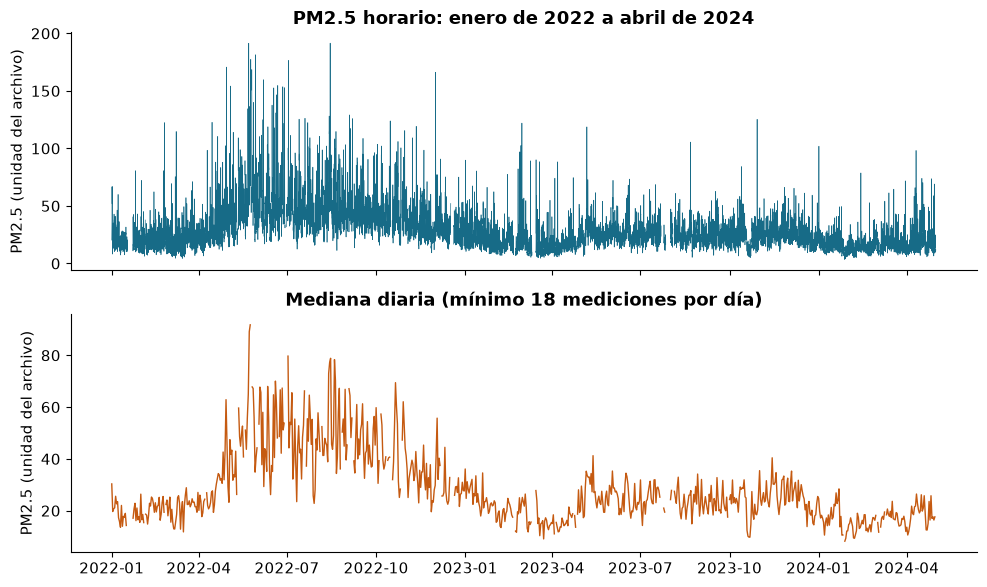

,count,mean,median,q25,q75,horas_esperadas,cobertura_pct
fecha_hora,,,,,,,
0,817,23.446,20.410,15.560,28.750,851,96.005
1,816,26.102,22.880,17.620,30.935,851,95.887
2,807,28.420,25.120,19.430,33.400,851,94.830
3,798,29.784,26.240,20.398,34.380,851,93.772
4,797,30.107,26.120,19.980,34.780,851,93.655
5,798,30.118,25.690,19.060,35.465,851,93.772
6,798,30.266,25.030,18.465,35.258,851,93.772
7,798,29.820,24.400,18.038,34.378,851,93.772
8,797,29.830,24.370,17.880,34.940,851,93.655


,count,mean,median,q25,q75,horas_esperadas,cobertura_pct
Lun,2763,28.441,23.590,16.920,34.205,2928,94.365
Mar,2824,29.348,24.765,17.620,35.963,2928,96.448
Mié,2711,27.732,23.940,16.780,33.830,2904,93.354
Jue,2792,28.621,24.225,17.548,35.002,2904,96.143
Vie,2741,29.897,25.410,18.030,35.520,2904,94.387
Sáb,2792,31.185,25.735,18.108,37.942,2928,95.355
Dom,2768,29.769,24.250,17.085,36.190,2928,94.536


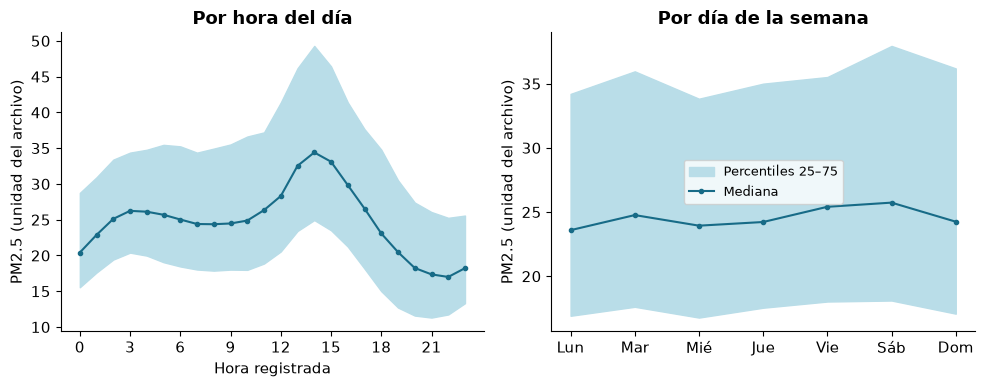

La mayor mediana horaria aparece a las **14:00** y la menor a las **22:00**. Las bandas muestran dispersión de las mediciones, no intervalos de confianza. Estas diferencias son descriptivas: no establecen causalidad ni demuestran una mejora predictiva.

In [8]:
diario = s.resample('D').agg(['count','median'])
diario['mediana_con_cobertura'] = diario['median'].where(diario['count'] >= 18)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(s.index, s, linewidth=.45, color=COLOR)
axes[0].set(ylabel=UNIDAD, title='PM2.5 horario: enero de 2022 a abril de 2024')
axes[1].plot(diario.index, diario.mediana_con_cobertura, linewidth=1, color='#C55A11')
axes[1].set(ylabel=UNIDAD, title='Mediana diaria (mínimo 18 mediciones por día)')
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
guardar(fig, '04_serie_temporal')

hora = s.groupby(s.index.hour).agg(['count','mean','median'])
hora['q25'] = s.groupby(s.index.hour).quantile(.25)
hora['q75'] = s.groupby(s.index.hour).quantile(.75)
hora['horas_esperadas'] = s.groupby(s.index.hour).size()
hora['cobertura_pct'] = 100*hora['count']/hora.horas_esperadas
tabla(hora, 'patron_horario')
semana = s.groupby(s.index.dayofweek).agg(['count','mean','median'])
semana['q25'] = s.groupby(s.index.dayofweek).quantile(.25)
semana['q75'] = s.groupby(s.index.dayofweek).quantile(.75)
semana['horas_esperadas'] = s.groupby(s.index.dayofweek).size()
semana['cobertura_pct'] = 100*semana['count']/semana.horas_esperadas
semana.index = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
tabla(semana, 'patron_semanal')
fig, axes = plt.subplots(1,2,figsize=(10,4))
for ax, t, x, titulo in [(axes[0],hora,np.arange(24),'Por hora del día'),
                         (axes[1],semana,np.arange(7),'Por día de la semana')]:
    ax.fill_between(x,t.q25.to_numpy(),t.q75.to_numpy(),color='#B9DDE8',label='Percentiles 25–75')
    ax.plot(x,t['median'],color=COLOR,marker='o',markersize=3,label='Mediana')
    ax.set(title=titulo,ylabel=UNIDAD)
axes[0].set_xticks(np.arange(0,24,3)); axes[0].set_xlabel('Hora registrada')
axes[1].set_xticks(np.arange(7),semana.index);axes[1].legend(fontsize=9)
guardar(fig, '05_patrones_calendario')
display(Markdown(f'La mayor mediana horaria aparece a las **{hora["median"].idxmax():02d}:00** '
                 f'y la menor a las **{hora["median"].idxmin():02d}:00**. '
                 'Las bandas muestran dispersión de las mediciones, no intervalos de confianza. '
                 'Estas diferencias son descriptivas: no establecen causalidad ni demuestran una mejora predictiva.'))


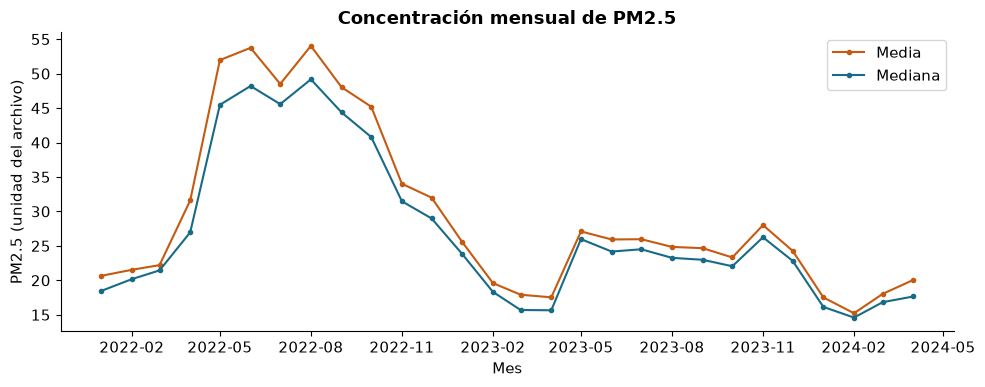

Cada punto resume las mediciones disponibles del mes. Debe leerse junto con la cobertura mensual: los meses tienen distinta cantidad de observaciones. Dos años completos y cuatro meses adicionales no bastan para afirmar que un patrón estacional se repetirá en otros periodos.

In [9]:
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(mensual.index,mensual['media'],label='Media',color='#C55A11',marker='o',markersize=3)
ax.plot(mensual.index,mensual['mediana'],label='Mediana',color=COLOR,marker='o',markersize=3)
ax.set(title='Concentración mensual de PM2.5',ylabel=UNIDAD,xlabel='Mes')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend()
guardar(fig, '06_resumen_mensual')
display(Markdown('Cada punto resume las mediciones disponibles del mes. Debe leerse junto con la cobertura mensual: '
                 'los meses tienen distinta cantidad de observaciones. Dos años completos y cuatro meses adicionales '
                 'no bastan para afirmar que un patrón estacional se repetirá en otros periodos.'))


### Relación entre horas consecutivas
Al mantener la rejilla completa, `shift(-1)` corresponde exactamente a una hora después. Se descartan pares incompletos solo para este gráfico; la serie original conserva sus faltantes. Esta relación describe dependencia temporal, no es una evaluación de modelos.


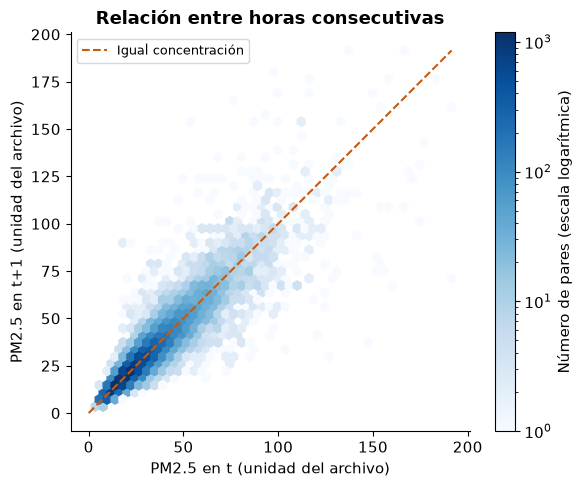

Hay **19,343 pares horarios completos**. La correlación de Pearson es **0.912**. Esta dependencia justifica comparar los modelos con la persistencia (usar el valor de la hora actual como pronóstico de la siguiente), sin anticipar cuál funcionará mejor.

In [10]:
pares = pd.DataFrame({'PM25_t':s,'PM25_t_mas_1':s.shift(-1)}).dropna()
correlacion = pares.PM25_t.corr(pares.PM25_t_mas_1)
fig, ax = plt.subplots(figsize=(6,5))
hb = ax.hexbin(pares.PM25_t,pares.PM25_t_mas_1,gridsize=45,mincnt=1,bins='log',cmap='Blues')
lim = max(pares.max())
ax.plot([0,lim],[0,lim],'--',color='#C55A11',label='Igual concentración')
fig.colorbar(hb,ax=ax,label='Número de pares (escala logarítmica)')
ax.set(xlabel='PM2.5 en t (unidad del archivo)',ylabel='PM2.5 en t+1 (unidad del archivo)',
       title='Relación entre horas consecutivas')
ax.legend(fontsize=9)
guardar(fig, '07_horas_consecutivas')
display(Markdown(f'Hay **{len(pares):,} pares horarios completos**. La correlación de Pearson es '
                 f'**{correlacion:.3f}**. Esta dependencia justifica comparar los modelos con la persistencia '
                 '(usar el valor de la hora actual como pronóstico de la siguiente), sin anticipar cuál funcionará mejor.'))


## 8. Sesgos y prevención de fuga de información

- **Cobertura espacial:** una estación no representa toda Lima. Las conclusiones se limitan a Santa Anita.
- **Selección temporal:** elegimos un periodo con alta disponibilidad. El comportamiento podría diferir en los años excluidos.
- **Faltantes:** se desconoce su mecanismo; si coinciden con episodios extremos, los resúmenes podrían estar sesgados. No se interpreta ausencia como concentración cero.
- **Medición:** faltan variables meteorológicas y detalles de mantenimiento. No atribuimos los cambios observados a tráfico, clima u otra causa específica.
- **Orden temporal:** en P2 se separarán entrenamiento, validación y prueba cronológicamente. No se mezclarán filas al azar.
- **Variables y transformaciones:** rezagos y medias móviles usarán solo información hasta el instante de predicción. Imputadores, escaladores y umbrales aprendidos se ajustarán con entrenamiento. No se interpolará usando mediciones futuras.
- **Respuesta:** la concentración de la siguiente hora se usará como etiqueta, nunca como entrada. La hora y el día de esa fecha sí son conocidos de antemano.
- **Evaluación:** se compararán modelos en las mismas horas con respuesta observada. Para la persistencia se debe definir cómo proceder cuando falta la medición actual; no se equiparará sin explicación con una medición antigua.
- **Alcance de este EDA:** se exploró todo el periodo seleccionado. Por tanto, su tramo final ya no es completamente desconocido. En P2 habrá que documentar esta exposición, fijar el protocolo antes de entrenar y evitar seleccionar modelos según sus resultados de prueba; si se dispone de datos posteriores adecuados, podrán reservarse para una comprobación adicional.

La variable objetivo es continua. No se crean clases de calidad del aire ni se evalúa balance de clases.


## 9. Hallazgos y próximos pasos


In [11]:
display(Markdown(f"""
1. **Disponibilidad:** {s.count():,} de {len(s):,} horas tienen PM2.5 ({100*s.notna().mean():.2f}%). Hay {s.isna().sum():,} faltantes y la mayor interrupción dura {max_hueco} horas.
2. **Calidad temporal:** el periodo seleccionado no contiene duplicados horarios y tiene {horas_sin_fila} horas sin fila. Los duplicados del archivo histórico quedan fuera del intervalo.
3. **Distribución:** media {s.mean():.2f}, mediana {s.median():.2f} y máximo {s.max():.2f}, en la unidad del archivo. La regla IQR señala {atipicos.sum():,} mediciones, que se conservan.
4. **Dependencia temporal:** se observan {len(pares):,} pares completos separados por una hora, con correlación {correlacion:.3f}. Esto respalda la inclusión de una referencia de persistencia en P2.
5. **Calendario:** los gráficos permiten explorar diferencias horarias y semanales, pero su aporte predictivo sigue siendo una hipótesis por evaluar.

**Siguiente etapa:** confirmar la unidad, fijar los periodos de evaluación y el tratamiento de faltantes, construir los rezagos y comparar al menos dos modelos con la persistencia. No se entrenaron modelos en esta entrega.
"""))
assert hashlib.sha256(CSV.read_bytes()).hexdigest() == hash_original
print('El CSV de entrada permanece intacto.')



1. **Disponibilidad:** 19,391 de 20,424 horas tienen PM2.5 (94.94%). Hay 1,033 faltantes y la mayor interrupción dura 126 horas.
2. **Calidad temporal:** el periodo seleccionado no contiene duplicados horarios y tiene 0 horas sin fila. Los duplicados del archivo histórico quedan fuera del intervalo.
3. **Distribución:** media 29.29, mediana 24.50 y máximo 191.50, en la unidad del archivo. La regla IQR señala 1,126 mediciones, que se conservan.
4. **Dependencia temporal:** se observan 19,343 pares completos separados por una hora, con correlación 0.912. Esto respalda la inclusión de una referencia de persistencia en P2.
5. **Calendario:** los gráficos permiten explorar diferencias horarias y semanales, pero su aporte predictivo sigue siendo una hipótesis por evaluar.

**Siguiente etapa:** confirmar la unidad, fijar los periodos de evaluación y el tratamiento de faltantes, construir los rezagos y comparar al menos dos modelos con la persistencia. No se entrenaron modelos en esta entrega.


El CSV de entrada permanece intacto.


## Gráficos para el informe

| Archivo en `figures/` | Ubicación sugerida | Qué respalda |
|---|---|---|
| `01_cobertura_anual` | Selección de estación y periodo | Diferencias de disponibilidad histórica; 2024 incluye enero–mayo. |
| `02_cobertura_mensual` | Calidad de datos | Concentración temporal de faltantes. |
| `03_distribucion_pm25` | Estadísticas y atípicos | Forma de la distribución y dispersión, sin eliminar extremos. |
| `04_serie_temporal` | Comportamiento temporal | Evolución horaria y mediana diaria con cobertura mínima. |
| `05_patrones_calendario` | Patrones por hora y día | Medianas y percentiles 25–75; no prueba mejora predictiva. |
| `06_resumen_mensual` | Comportamiento temporal, opcional | Medias y medianas por mes. |
| `07_horas_consecutivas` | Dependencia temporal, opcional | Relación entre la medición actual y la siguiente. |

Usar el PDF vectorial en LaTeX o el PNG en las diapositivas. Para ahorrar espacio, se pueden elegir los cinco primeros. Las tablas exportadas permiten trasladar los valores al informe sin transcribirlos de los gráficos. Antes de entregar, confirmar la unidad y actualizar el texto del resumen para reflejar los hallazgos del EDA.
